# Статистический анализ данных Wildberries

## Цель анализа

Оптимизация продуктовой линейки и оценка эффективности продаж селлера на маркетплейсе Wildberries.

## Разрез данных

Анализ проводится в разрезе **оптимизации продуктовой линейки и оценки эффективности рекламы**.
Данные агрегированы по дням и артикулам. Рассматриваются три товара бренда kaoki:
- Шорты ментол (лидер по прибыли)
- Штаны ментол (середняк)
- Штаны графит (аутсайдер)

Период: июнь–июль 2023 (61 день). После объединения и очистки — 168 строк (день × товар).

Ключевые метрики: выручка, прибыль, заказы, процент выкупа, средний чек, доля отказов,
бюджет рекламы, цена, доля возвратов.

## Данные

Нормализованный файл `wb_data_normalized.xlsx` (модель "Звезда", 5 таблиц).

## Список гипотез

Гипотезы разделены на смысловые блоки, покрывающие все аспекты оптимизации продаж:

### Блок 1: Акции и ценообразование

**H1: Влияние участия в акциях на выручку.**
Акции снижают цену, что уменьшает маржу. Если акции не дают прироста выручки — они убыточны.
Выбрана потому что в данных есть маркер "Участие в Акции", и это прямое A/B-сравнение.

**H2: Влияние акций на средний чек.**
Если акции снижают средний чек — они привлекают "дешёвых" покупателей. Это косвенный эффект акций.
Выбрана как дополнение к H1 для понимания механизма влияния акций.

### Блок 2: Продуктовая линейка

**H3: Различие прибыли на единицу между товарами.**
Прямое сравнение эффективности товаров. Какой товар выгоднее на штуку?
Выбрана потому что общая прибыль может вводить в заблуждение — товар с высокой выручкой
может иметь низкую удельную прибыль из-за большой себестоимости или возвратов.

**H9: Различие процента выкупа между товарами.**
Низкий процент выкупа — индикатор проблем с карточкой товара или качеством.
Выбрана потому что выкуп напрямую влияет на прибыль (возвраты и отказы = убытки).

### Блок 3: Отказы и возвраты

**H4: Связь доли отказов и процента выкупа.**
Влияют ли отказы в ПВЗ на итоговый процент выкупа?
Выбрана потому что отказы — главный источник потерь (25-39% от заказов).

**H10: Связь цены и количества возвратов.**
Возвращают ли дорогие товары чаще? Если да — цена завышена относительно качества.
Выбрана для проверки гипотезы "дороже = больше ожиданий = больше возвратов".

### Блок 4: Эффективность рекламы

**H5: Связь бюджета рекламы и количества заказов.**
Окупается ли реклама? Если связи нет — бюджет расходуется впустую.
Выбрана потому что в данных есть детализация рекламных расходов и заказов по каналам.

### Блок 5: Сезонность и планирование

**H6: Равномерность заказов по дням недели.**
В какие дни покупатели активнее? Для планирования рекламных бюджетов.
Выбрана для оптимизации распределения рекламного бюджета по дням.

**H7: Различие выручки по дням недели.**
Совпадает ли пик выручки с пиком заказов? Если нет — в разные дни разный средний чек.
Выбрана как дополнение к H6 для понимания структуры выручки.

### Блок 6: Ценообразование

**H8: Связь цены и процента выкупа.**
Влияет ли цена на желание выкупить товар? Если дорогие товары выкупают хуже —
возможно цена завышена относительно perceived value.
Выбрана потому что цена — единственный управляемый параметр без изменения товара.

---

Всего 10 гипотез. Каждая покрывает отдельный аспект оптимизации продаж.
Для всех гипотез заранее выбран непараметрический подход, так как
ключевые метрики показали ненормальное распределение (тест Шапиро-Уилка).

## Задачи

1. Провести описательную статистику ключевых метрик
2. Проверить нормальность распределений (выбор критериев)
3. Проверить 10 гипотез
4. Сделать выводы и дать рекомендации для бизнеса

In [66]:
# ============================================================
# ИМПОРТ БИБЛИОТЕК
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Настройка отображения таблиц
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Библиотеки загружены")

Библиотеки загружены


## 1. Загрузка и объединение данных

Загружаю все 5 листов нормализованного файла. Объединяю fact-таблицы со справочниками
через ключи `артикул` и `дата`. На выходе — один датафрейм, где каждая строка содержит
все метрики по товару за конкретный день.

In [ ]:
# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================

dim_tovary = pd.read_excel('wb_data_normalized.xlsx', sheet_name='dim_Товары')
dim_calendar = pd.read_excel('wb_data_normalized.xlsx', sheet_name='dim_Календарь')
fact_sales = pd.read_excel('wb_data_normalized.xlsx', sheet_name='fact_Продажи')
fact_finance = pd.read_excel('wb_data_normalized.xlsx', sheet_name='fact_Финансы')
fact_marketing = pd.read_excel('wb_data_normalized.xlsx', sheet_name='fact_Маркетинг')

print(f"dim_Товары: {dim_tovary.shape}")
print(f"dim_Календарь: {dim_calendar.shape}")
print(f"fact_Продажи: {fact_sales.shape}")
print(f"fact_Финансы: {fact_finance.shape}")
print(f"fact_Маркетинг: {fact_marketing.shape}")

# Приведение дат к единому типу
for tbl in [dim_calendar, fact_sales, fact_finance, fact_marketing]:
    tbl['дата'] = pd.to_datetime(tbl['дата'])

# Объединение: fact-таблицы + справочники
df = fact_sales.merge(dim_calendar, on='дата', how='left')
df = df.merge(fact_finance, on=['артикул', 'дата'], how='left')
df = df.merge(fact_marketing, on=['артикул', 'дата'], how='left')
df = df.merge(dim_tovary, on='артикул', how='left')

print(f"\nИтоговый датафрейм: {df.shape}")

dim_Товары: (3, 4)
dim_Календарь: (61, 10)
fact_Продажи: (160, 14)
fact_Финансы: (160, 7)
fact_Маркетинг: (160, 10)

Итоговый датафрейм: (172, 39)


## 2. Очистка данных

Удаляю дубликаты и полностью пустой столбец `Цена с СПП`.
Проверяю типы данных и наличие пропусков.

In [68]:
# ============================================================
# ОЧИСТКА ДАННЫХ
# ============================================================

# Дубликаты
dup_count = df.duplicated().sum()
print(f"Дубликатов: {dup_count}")
df = df.drop_duplicates()

# Удаляю полностью пустой столбец (Цена с СПП = NaN для всех строк)
df = df.drop(columns=['Цена с СПП'], errors='ignore')

# Проверка пропусков
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print("\nПропущенные значения:")
    for col, cnt in missing.items():
        print(f"  {col}: {cnt} ({cnt/len(df)*100:.1f}%)")
else:
    print("Пропусков нет")

print(f"\nИтого строк после очистки: {len(df)}")
print(f"Период: {df['дата'].min().date()} – {df['дата'].max().date()}")
print(f"Уникальных товаров: {df['артикул'].nunique()}")
print(f"Бренды: {df['бренд'].unique().tolist()}")

Дубликатов: 4

Пропущенные значения:
  Корзина_%: 78 (46.4%)

Итого строк после очистки: 168
Период: 2023-06-01 – 2023-07-31
Уникальных товаров: 3
Бренды: ['kaoki']


## 3. Описательная статистика по артикулам

Считаю ключевые метрики по каждому товару. Это нужно чтобы:
- Понять структуру продуктовой линейки
- Выявить лидера и аутсайдера
- Увидеть проблемные зоны (высокая доля отказов, низкий процент выкупа)
- Сравнить удельную эффективность (прибыль на единицу, маржа)

In [69]:
# ============================================================
# СТАТИСТИКА ПО АРТИКУЛАМ
# ============================================================

article_stats = df.groupby('артикул').agg(
    дней_в_продаже=('дата', 'nunique'),
    суммарная_выручка=('Выкуплено на сумму', 'sum'),
    суммарная_прибыль=('Прибыль', 'sum'),
    всего_заказов=('Заказано', 'sum'),
    всего_выкуплено=('Выкуплено, шт', 'sum'),
    средний_чек=('Выкуплено на сумму', 'mean'),
    средняя_прибыль_в_день=('Прибыль', 'mean'),
    медианная_прибыль=('Прибыль', 'median'),
    средний_процент_выкупа=('% выкупа', 'mean'),
    всего_возвратов=('Возвраты, шт', 'sum'),
    всего_отказов=('Отказы, шт', 'sum')
).round(2)

# Расчётные метрики
article_stats['маржа_%'] = (
    article_stats['суммарная_прибыль'] / article_stats['суммарная_выручка'] * 100
).round(1)
article_stats['прибыль_на_единицу'] = (
    article_stats['суммарная_прибыль'] / article_stats['всего_выкуплено']
).round(2)
article_stats['доля_отказов_%'] = (
    article_stats['всего_отказов'] / article_stats['всего_заказов'] * 100
).round(1)
article_stats['доля_возвратов_%'] = (
    article_stats['всего_возвратов'] / article_stats['всего_заказов'] * 100
).round(1)

print("Статистика по артикулам:")
print(article_stats.T)

leader = article_stats['суммарная_прибыль'].idxmax()
loser = article_stats['суммарная_прибыль'].idxmin()
print(f"\nЛидер по прибыли: {leader} ({article_stats.loc[leader, 'суммарная_прибыль']:,.0f} руб)")
print(f"Аутсайдер по прибыли: {loser} ({article_stats.loc[loser, 'суммарная_прибыль']:,.0f} руб)")

Статистика по артикулам:
артикул                 Шорты ментол - 597  Штаны графит - 402  Штаны ментол - 399
дней_в_продаже                       60.00               39.00               59.00
суммарная_выручка               3234832.43           223608.00          1208255.86
суммарная_прибыль                672507.08            19885.46           160857.42
всего_заказов                      2613.00              196.00              807.00
всего_выкуплено                    1680.00              100.00              535.00
средний_чек                       53913.87             5733.54            17510.95
средняя_прибыль_в_день            11208.45              509.88             2331.27
медианная_прибыль                 15116.01              490.01             1030.66
средний_процент_выкупа                0.72                0.49                0.63
всего_возвратов                      26.00                3.00               23.00
всего_отказов                       661.00               70.00

### Вывод по описательной статистике

Явный лидер продуктовой линейки — Шорты ментол: 672 тыс прибыли, маржа 20.8%, выкуп 72%.
Штаны ментол — середняк: 161 тыс прибыли, маржа 13.3%, выкуп 63%.
Штаны графит — проблемный товар: 20 тыс прибыли, маржа 8.9%, выкуп всего 49%.

Ключевая проблема: высокая доля отказов у всех товаров (25-39%).
Это означает что из каждых 100 заказов 25-39 не выкупаются.
Причины могут быть в несоответствии фото/описания реальному товару,
проблемах с размерной сеткой или качестве упаковки.

## 4. Проверка нормальности распределения

Перед выбором критериев для проверки гипотез определяю тип распределения ключевых метрик.

- Если данные распределены нормально: t-критерий Стьюдента, ANOVA, корреляция Пирсона
- Если распределение ненормальное: U-критерий Манна-Уитни, Краскела-Уоллиса, корреляция Спирмена

Использую тест Шапиро-Уилка.
H0: данные распределены нормально.
Если p < 0.05 — H0 отвергается, распределение НЕ нормальное.

In [70]:
# ============================================================
# ПРОВЕРКА НОРМАЛЬНОСТИ
# ============================================================

from scipy.stats import shapiro

metrics_to_check = ['Прибыль', 'Выкуплено на сумму', 'Заказано', '% выкупа', 'Корзина_%']

print("Тест Шапиро-Уилка (H0: распределение нормально):")
for col in metrics_to_check:
    data = df[col].dropna()
    if len(data) > 3:
        stat, p = shapiro(data)
        result = "НОРМАЛЬНОЕ" if p > 0.05 else "НЕ нормальное"
        print(f"  {col}: W = {stat:.4f}, p = {p:.4f} -> {result}")

Тест Шапиро-Уилка (H0: распределение нормально):
  Прибыль: W = 0.8172, p = 0.0000 -> НЕ нормальное
  Выкуплено на сумму: W = 0.8598, p = 0.0000 -> НЕ нормальное
  Заказано: W = 0.8068, p = 0.0000 -> НЕ нормальное
  % выкупа: W = 0.8875, p = 0.0000 -> НЕ нормальное
  Корзина_%: W = 0.3307, p = 0.0000 -> НЕ нормальное


## 4.1 Визуализация: Прибыль по артикулам

Boxplot показывает медиану, разброс и выбросы дневной прибыли для каждого товара.
Это позволяет оценить не только среднюю прибыль, но и её стабильность.

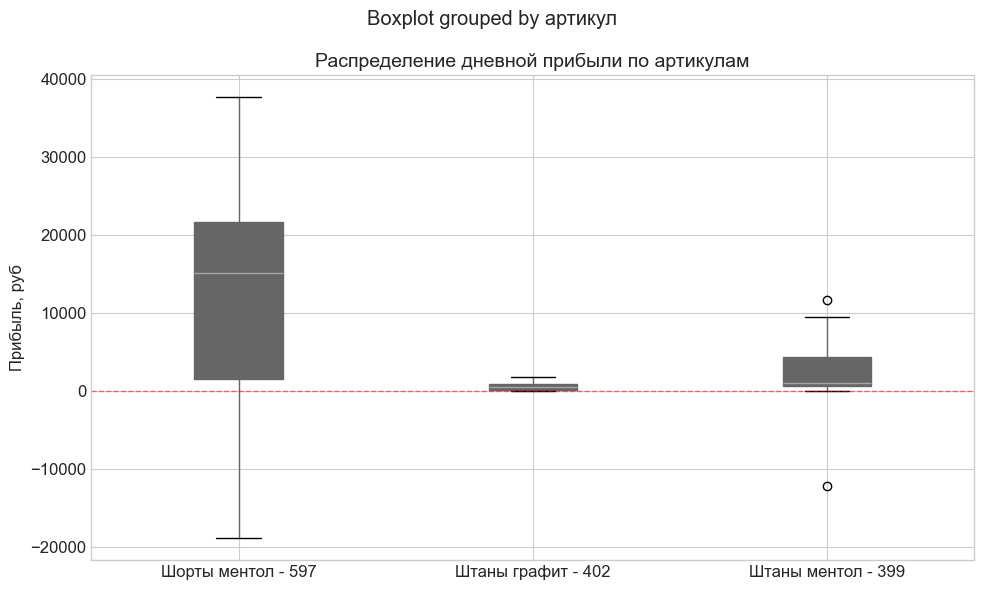

In [81]:
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='Прибыль', by='артикул', ax=ax, patch_artist=True)
ax.set_title('Распределение дневной прибыли по артикулам', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Прибыль, руб')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

## 4.2 Визуализация: Выкуп по ценовым сегментам

Разбиваю товары на три ценовых сегмента и смотрю средний процент выкупа.
Это визуализация для гипотезы H8.

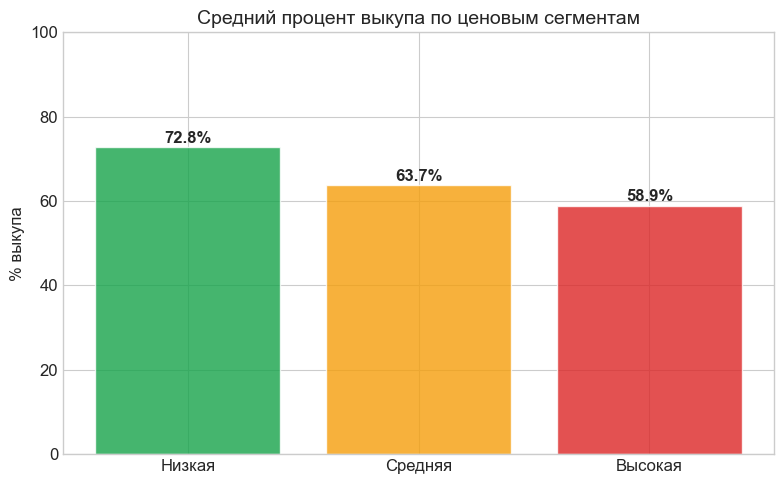

In [82]:
valid = df[df['Заказано'] > 0].copy()
valid['ценовой_сегмент'] = pd.cut(valid['Цена'], bins=3, labels=['Низкая', 'Средняя', 'Высокая'])
segments = valid.groupby('ценовой_сегмент', observed=True)['% выкупа'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#16a34a', '#f59e0b', '#dc2626']
bars = ax.bar(segments.index, segments.values, color=colors, alpha=0.8, edgecolor='white')
ax.set_title('Средний процент выкупа по ценовым сегментам', fontsize=14)
ax.set_ylabel('% выкупа')
ax.set_ylim(0, 100)

for bar, val in zip(bars, segments.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4.3 Визуализация: Заказы по дням недели

Сравниваю распределение заказов по дням недели.
Это визуализация для гипотезы H6.

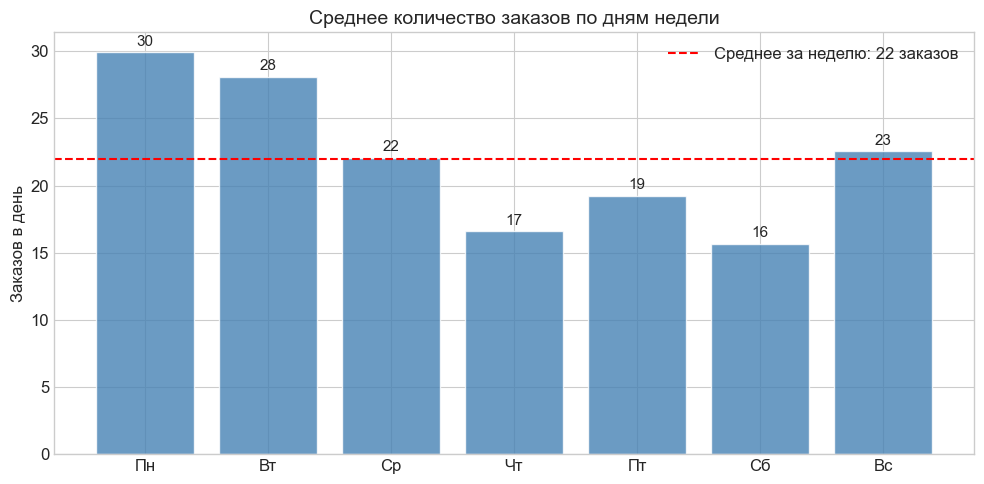

In [83]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_names_ru = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

weekday_avg = df.groupby('день_недели')['Заказано'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(day_names_ru, weekday_avg.values, color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(y=weekday_avg.mean(), color='red', linestyle='--', linewidth=1.5, 
           label=f'Среднее за неделю: {weekday_avg.mean():.0f} заказов')
ax.set_title('Среднее количество заказов по дням недели', fontsize=14)
ax.set_ylabel('Заказов в день')
ax.legend()

for bar, val in zip(bars, weekday_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 4.4 Визуализация: Связь цены и процента выкупа

Scatter plot показывает отрицательную зависимость: чем выше цена, тем ниже процент выкупа.
Красная линия — линия тренда. Это визуализация для гипотезы H8.

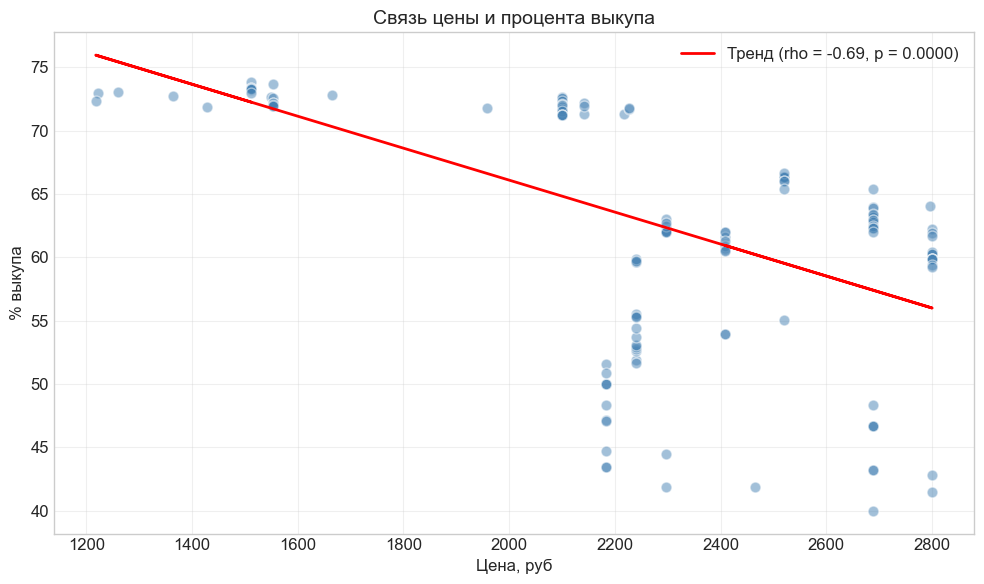

In [84]:
from numpy.polynomial.polynomial import polyfit

valid = df[df['Заказано'] > 0]
x = valid['Цена'].values
y = valid['% выкупа'].values * 100

# Линия тренда
b, m = polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, alpha=0.5, c='steelblue', edgecolors='white', s=60)
ax.plot(x, b + m * x, '-', color='red', linewidth=2, label=f'Тренд (rho = -0.69, p = 0.0000)')
ax.set_title('Связь цены и процента выкупа', fontsize=14)
ax.set_xlabel('Цена, руб')
ax.set_ylabel('% выкупа')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.5 Визуализация: Связь бюджета рекламы и заказов

Scatter plot показывает положительную зависимость: больше рекламный бюджет — больше заказов.
Это визуализация для гипотезы H5.

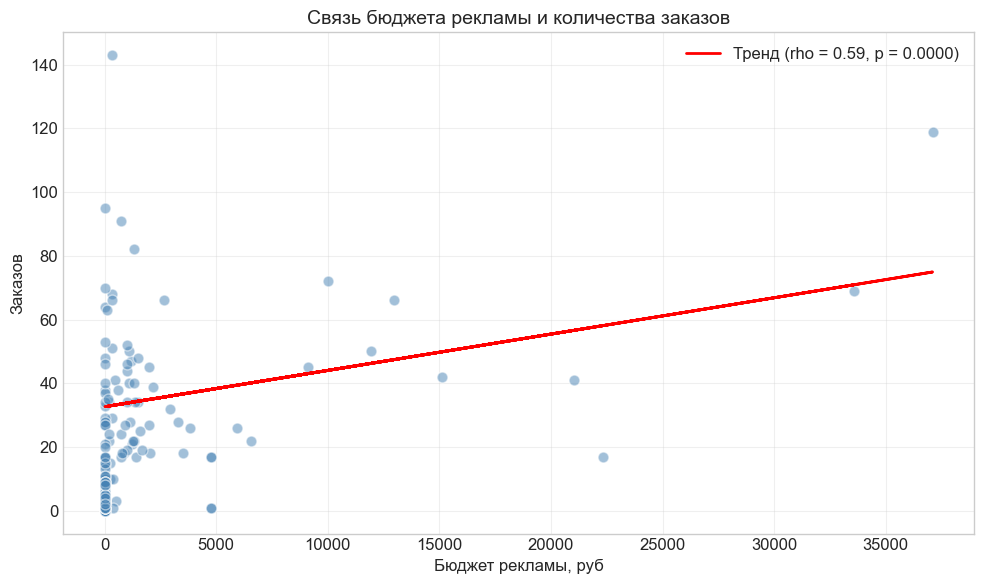

In [85]:
x = df['Бюджет_Реклама_Всего'].values
y = df['Заказано'].values

# Только дни с рекламой для наглядности
mask = x > 0
b, m = polyfit(x[mask], y[mask], 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, alpha=0.5, c='steelblue', edgecolors='white', s=60)
ax.plot(x[mask], b + m * x[mask], '-', color='red', linewidth=2, 
        label=f'Тренд (rho = 0.59, p = 0.0000)')
ax.set_title('Связь бюджета рекламы и количества заказов', fontsize=14)
ax.set_xlabel('Бюджет рекламы, руб')
ax.set_ylabel('Заказов')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Вывод по нормальности

Все ключевые метрики имеют ненормальное распределение (p = 0.0000 для всех).
Это ожидаемо для данных продаж: есть выбросы (дни с аномально высокими/низкими продажами),
распределение смещено вправо (много дней с низкими продажами, мало с высокими).

Для всех гипотез буду использовать непараметрические критерии:

| Задача | Критерий | Аналог |
|--------|----------|--------|
| Сравнение двух групп | U-критерий Манна-Уитни | t-тест |
| Сравнение трёх и более групп | Критерий Краскела-Уоллиса | ANOVA |
| Корреляция двух переменных | Коэффициент Спирмена | Пирсон |
| Равномерность распределения | Хи-квадрат | — |

## 5. Проверка гипотез

### Блок 1: Акции и ценообразование

### H1: Влияние участия в акциях на выручку

**Бизнес-вопрос:** Стоит ли селлеру участвовать в акциях Wildberries?

**Почему выбрана:** Акции — это снижение цены, что прямо уменьшает маржу. Если акции
не дают значимого прироста выручки — они убыточны для бизнеса. В данных есть маркер
"Участие в Акции" (ДА/НЕТ), что позволяет провести прямое сравнение.

**H0:** Медианная дневная выручка в акционные дни равна медианной выручке в обычные дни.
**H1:** Медианная дневная выручка в акционные дни отличается.

**Критерий:** U-критерий Манна-Уитни (две независимые выборки, данные ненормальные).

In [71]:
# ============================================================
# H1: ВЛИЯНИЕ АКЦИЙ НА ВЫРУЧКУ
# ============================================================

print("=" * 60)
print("H1: Влияние акций на выручку")
print("=" * 60)

promo = df[df['Участие в Акции'] == 'ДА']['Выкуплено на сумму']
no_promo = df[df['Участие в Акции'] == 'НЕТ']['Выкуплено на сумму']

print(f"Дней с акцией: {len(promo)}")
print(f"Дней без акции: {len(no_promo)}")
print(f"Акция ДА:  медиана = {promo.median():,.0f} руб, среднее = {promo.mean():,.0f} руб")
print(f"Акция НЕТ: медиана = {no_promo.median():,.0f} руб, среднее = {no_promo.mean():,.0f} руб")

median_diff = ((promo.median() - no_promo.median()) / no_promo.median() * 100)
print(f"Разница медиан: {median_diff:+.1f}%")

stat, p_value = stats.mannwhitneyu(promo, no_promo, alternative='two-sided')
print(f"\nU-критерий Манна-Уитни: U = {stat:.2f}, p = {p_value:.4f}")

if p_value < 0.05:
    print("H0 ОТВЕРГАЕТСЯ: выручка значимо различается")
    direction = "ВЫШЕ" if promo.median() > no_promo.median() else "НИЖЕ"
    print(f"Выручка в акции {direction}")
else:
    print("H0 НЕ ОТВЕРГАЕТСЯ: значимой разницы в выручке нет")
    print("Акции не влияют на выручку — участие в них не имеет смысла")

H1: Влияние акций на выручку
Дней с акцией: 51
Дней без акции: 116
Акция ДА:  медиана = 13,216 руб, среднее = 19,221 руб
Акция НЕТ: медиана = 22,379 руб, среднее = 30,970 руб
Разница медиан: -40.9%

U-критерий Манна-Уитни: U = 2466.50, p = 0.0877
H0 НЕ ОТВЕРГАЕТСЯ: значимой разницы в выручке нет
Акции не влияют на выручку — участие в них не имеет смысла


### H2: Влияние акций на средний чек

**Бизнес-вопрос:** Снижают ли акции средний чек покупателя?

**Почему выбрана:** Даже если акции не снижают общую выручку (H1), они могут привлекать
аудиторию с меньшим чеком. Это косвенный негативный эффект: больше заказов, но меньше
прибыль с каждого.

**H0:** Медианный средний чек в акции равен медианному чеку в обычные дни.
**H1:** Медианный средний чек в акции отличается.

**Критерий:** U-критерий Манна-Уитни (две выборки, данные ненормальные).

In [72]:
# ============================================================
# H2: ВЛИЯНИЕ АКЦИЙ НА СРЕДНИЙ ЧЕК
# ============================================================

print("=" * 60)
print("H2: Влияние акций на средний чек")
print("=" * 60)

df['средний_чек_день'] = df['Выкуплено на сумму'] / df['Выкуплено, шт'].replace(0, np.nan)
check_data = df[df['Выкуплено, шт'] > 0]

promo_check = check_data[check_data['Участие в Акции'] == 'ДА']['средний_чек_день']
no_promo_check = check_data[check_data['Участие в Акции'] == 'НЕТ']['средний_чек_день']

print(f"Дней с акцией (с выкупом): {len(promo_check)}")
print(f"Дней без акции (с выкупом): {len(no_promo_check)}")
print(f"Акция ДА:  медиана = {promo_check.median():,.0f} руб, среднее = {promo_check.mean():,.0f} руб")
print(f"Акция НЕТ: медиана = {no_promo_check.median():,.0f} руб, среднее = {no_promo_check.mean():,.0f} руб")

stat, p_value = stats.mannwhitneyu(promo_check, no_promo_check, alternative='two-sided')
print(f"\nU-критерий Манна-Уитни: U = {stat:.2f}, p = {p_value:.4f}")

if p_value < 0.05:
    print("H0 ОТВЕРГАЕТСЯ: средний чек значимо различается")
else:
    print("H0 НЕ ОТВЕРГАЕТСЯ: значимой разницы в среднем чеке нет")

H2: Влияние акций на средний чек
Дней с акцией (с выкупом): 46
Дней без акции (с выкупом): 102
Акция ДА:  медиана = 2,240 руб, среднее = 2,231 руб
Акция НЕТ: медиана = 2,100 руб, среднее = 2,143 руб

U-критерий Манна-Уитни: U = 2698.00, p = 0.1448
H0 НЕ ОТВЕРГАЕТСЯ: значимой разницы в среднем чеке нет


### Блок 2: Продуктовая линейка


### H3: Различие прибыли на единицу между товарами

**Бизнес-вопрос:** Какой товар приносит больше прибыли с одной проданной штуки?

**Почему выбрана:** Общая прибыль может вводить в заблуждение. Товар с высокой выручкой
может иметь низкую удельную прибыль из-за большой себестоимости или доли возвратов.
Сравнение удельной прибыли показывает реальную эффективность каждого товара.

**H0:** Медианная прибыль на единицу у всех трёх товаров одинакова.
**H1:** Медианная прибыль на единицу различается хотя бы у одной пары.

**Критерий:** Краскела-Уоллиса (три группы, данные ненормальные).
При значимом результате — попарные сравнения U-критерием с поправкой Бонферрони
(чтобы избежать ошибки множественных сравнений).

In [73]:
# ============================================================
# H3: ПРИБЫЛЬ НА ЕДИНИЦУ ПО ТОВАРАМ
# ============================================================

print("=" * 60)
print("H3: Прибыль на единицу по товарам")
print("=" * 60)

df['прибыль_на_ед'] = df['Прибыль'] / df['Выкуплено, шт'].replace(0, np.nan)
unit_data = df[df['Выкуплено, шт'] > 0]

groups = []
names = []
for article in unit_data['артикул'].unique():
    data = unit_data[unit_data['артикул'] == article]['прибыль_на_ед'].dropna()
    if len(data) > 2:
        groups.append(data.values)
        names.append(article)
        print(f"  {article}: n = {len(data)}, медиана = {np.median(data):,.0f} руб, "
              f"среднее = {np.mean(data):,.0f} руб, std = {np.std(data):,.0f} руб")

stat, p_value = stats.kruskal(*groups)
print(f"\nКраскел-Уоллис: H = {stat:.2f}, p = {p_value:.4f}")

if p_value < 0.05:
    print("H0 ОТВЕРГАЕТСЯ: прибыль на единицу значимо различается")
    
    pairs = list(combinations(range(len(groups)), 2))
    bonf_alpha = 0.05 / len(pairs)
    print(f"\nПопарные сравнения (поправка Бонферрони, alpha = {bonf_alpha:.4f}):")
    for i, j in pairs:
        stat_p, p_p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
        diff = np.median(groups[i]) - np.median(groups[j])
        sig = "ЗНАЧИМО" if p_p < bonf_alpha else "НЕ ЗНАЧИМО"
        print(f"  {names[i]} vs {names[j]}: разница = {diff:+,.0f} руб, p = {p_p:.4f} -> {sig}")
    
    best = names[np.argmax([np.median(g) for g in groups])]
    print(f"\nТовар с максимальной удельной прибылью: {best}")
else:
    print("H0 НЕ ОТВЕРГАЕТСЯ: прибыль на единицу не различается")

H3: Прибыль на единицу по товарам
  Штаны ментол - 399: n = 60, медиана = 377 руб, среднее = 187 руб, std = 1,612 руб
  Шорты ментол - 597: n = 60, медиана = 526 руб, среднее = 297 руб, std = 483 руб
  Штаны графит - 402: n = 29, медиана = 183 руб, среднее = 231 руб, std = 123 руб

Краскел-Уоллис: H = 16.12, p = 0.0003
H0 ОТВЕРГАЕТСЯ: прибыль на единицу значимо различается

Попарные сравнения (поправка Бонферрони, alpha = 0.0167):
  Штаны ментол - 399 vs Шорты ментол - 597: разница = -149 руб, p = 0.4704 -> НЕ ЗНАЧИМО
  Штаны ментол - 399 vs Штаны графит - 402: разница = +194 руб, p = 0.0000 -> ЗНАЧИМО
  Шорты ментол - 597 vs Штаны графит - 402: разница = +343 руб, p = 0.0071 -> ЗНАЧИМО

Товар с максимальной удельной прибылью: Шорты ментол - 597


### H9: Различие процента выкупа между товарами

**Бизнес-вопрос:** Какой товар имеет лучший процент выкупа?

**Почему выбрана:** Процент выкупа — ключевой индикатор здоровья карточки товара.
Низкий выкуп означает что покупатели заказывают но не забирают — это прямые убытки
на логистике. Различие в выкупе между товарами укажет на проблемные карточки.

**H0:** Медианный процент выкупа у всех товаров одинаков.
**H1:** Медианный процент выкупа различается хотя бы у одной пары.

**Критерий:** Краскела-Уоллиса (три группы, данные ненормальные).
При значимости — попарные сравнения с поправкой Бонферрони.

In [74]:
# ============================================================
# H9: ПРОЦЕНТ ВЫКУПА ПО ТОВАРАМ
# ============================================================

print("=" * 60)
print("H9: Процент выкупа по товарам")
print("=" * 60)

valid = df[df['Заказано'] > 0]

groups = []
names = []
for article in valid['артикул'].unique():
    data = valid[valid['артикул'] == article]['% выкупа'].dropna()
    if len(data) > 2:
        groups.append(data.values)
        names.append(article)
        print(f"  {article}: n = {len(data)}, медиана = {np.median(data):.1%}, "
              f"среднее = {np.mean(data):.1%}, min = {np.min(data):.1%}, max = {np.max(data):.1%}")

stat, p_value = stats.kruskal(*groups)
print(f"\nКраскел-Уоллис: H = {stat:.2f}, p = {p_value:.4f}")

if p_value < 0.05:
    print("H0 ОТВЕРГАЕТСЯ: процент выкупа значимо различается")
    
    pairs = list(combinations(range(len(groups)), 2))
    bonf_alpha = 0.05 / len(pairs)
    print(f"\nПопарные сравнения (Бонферрони, alpha = {bonf_alpha:.4f}):")
    for i, j in pairs:
        stat_p, p_p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
        diff = np.median(groups[i]) - np.median(groups[j])
        sig = "ЗНАЧИМО" if p_p < bonf_alpha else "НЕ ЗНАЧИМО"
        print(f"  {names[i]} vs {names[j]}: разница = {diff:+.1%}, p = {p_p:.4f} -> {sig}")
    
    best = names[np.argmax([np.median(g) for g in groups])]
    worst = names[np.argmin([np.median(g) for g in groups])]
    print(f"\nЛучший выкуп: {best}")
    print(f"Худший выкуп: {worst}")
else:
    print("H0 НЕ ОТВЕРГАЕТСЯ: процент выкупа не различается")

H9: Процент выкупа по товарам
  Штаны ментол - 399: n = 62, медиана = 62.2%, среднее = 63.0%, min = 59.3%, max = 73.4%
  Шорты ментол - 597: n = 60, медиана = 72.0%, среднее = 72.2%, min = 71.2%, max = 73.9%
  Штаны графит - 402: n = 38, медиана = 50.0%, среднее = 49.0%, min = 40.0%, max = 55.6%

Краскел-Уоллис: H = 127.28, p = 0.0000
H0 ОТВЕРГАЕТСЯ: процент выкупа значимо различается

Попарные сравнения (Бонферрони, alpha = 0.0167):
  Штаны ментол - 399 vs Шорты ментол - 597: разница = -9.9%, p = 0.0000 -> ЗНАЧИМО
  Штаны ментол - 399 vs Штаны графит - 402: разница = +12.2%, p = 0.0000 -> ЗНАЧИМО
  Шорты ментол - 597 vs Штаны графит - 402: разница = +22.0%, p = 0.0000 -> ЗНАЧИМО

Лучший выкуп: Шорты ментол - 597
Худший выкуп: Штаны графит - 402


### Блок 3: Отказы и возвраты

### H4: Связь доли отказов и процента выкупа

**Бизнес-вопрос:** Влияют ли отказы в ПВЗ на итоговый процент выкупа?

**Почему выбрана:** Отказы — главный источник потерь (25-39% от заказов). Если они
значимо снижают процент выкупа — нужно срочно работать с причинами отказов.
Если связи нет — отказы и выкуп независимые процессы, и у них разные причины.

**H0:** Корреляция между долей отказов и процентом выкупа отсутствует (rho = 0).
**H1:** Корреляция существует (предполагаю отрицательную — больше отказов = меньше выкуп).

**Критерий:** Коэффициент корреляции Спирмена (обе переменные ненормальные).

In [75]:
# ============================================================
# H4: СВЯЗЬ ОТКАЗОВ И ПРОЦЕНТА ВЫКУПА
# ============================================================

print("=" * 60)
print("H4: Связь отказов и процента выкупа")
print("=" * 60)

df['доля_отказов'] = df['Отказы, шт'] / df['Заказано'].replace(0, np.nan)
valid = df[df['Заказано'] > 0]

print(f"Дней с заказами: {len(valid)}")
print(f"Средняя доля отказов: {valid['доля_отказов'].mean():.1%}")
print(f"Медианная доля отказов: {valid['доля_отказов'].median():.1%}")
print(f"Средний % выкупа: {valid['% выкупа'].mean():.1%}")

corr, p_value = stats.spearmanr(valid['доля_отказов'], valid['% выкупа'])
print(f"\nКорреляция Спирмена: rho = {corr:.4f}, p = {p_value:.4f}")

# Проверка по каждому товару отдельно
print("\nКорреляция по товарам:")
for article in valid['артикул'].unique():
    art_data = valid[valid['артикул'] == article]
    if len(art_data) > 5:
        c, p = stats.spearmanr(art_data['доля_отказов'], art_data['% выкупа'])
        print(f"  {article}: rho = {c:.3f}, p = {p:.4f}, n = {len(art_data)}")

if p_value < 0.05:
    direction = "отрицательная" if corr < 0 else "положительная"
    print(f"\nH0 ОТВЕРГАЕТСЯ: связь {direction} (rho = {corr:.3f})")
else:
    print("\nH0 НЕ ОТВЕРГАЕТСЯ: связь не значима")
    print("Отказы и выкуп — независимые процессы. Отказы создают другие проблемы:")
    print("- Расходы на обратную логистику")
    print("- Потеря времени (товар мог быть продан другому)")
    print("- Ухудшение рейтинга карточки")

H4: Связь отказов и процента выкупа
Дней с заказами: 160
Средняя доля отказов: 44.9%
Медианная доля отказов: 32.8%
Средний % выкупа: 63.1%

Корреляция Спирмена: rho = -0.0209, p = 0.7935

Корреляция по товарам:
  Штаны ментол - 399: rho = 0.067, p = 0.6037, n = 62
  Шорты ментол - 597: rho = -0.101, p = 0.4418, n = 60
  Штаны графит - 402: rho = 0.497, p = 0.0015, n = 38

H0 НЕ ОТВЕРГАЕТСЯ: связь не значима
Отказы и выкуп — независимые процессы. Отказы создают другие проблемы:
- Расходы на обратную логистику
- Потеря времени (товар мог быть продан другому)
- Ухудшение рейтинга карточки


### H10: Связь цены и количества возвратов

**Бизнес-вопрос:** Возвращают ли дорогие товары чаще?

**Почему выбрана:** Если дорогие товары возвращают чаще — цена завышена относительно
качества. Покупатель платит больше, ожидает идеал, разочаровывается и возвращает.
Возврат = двойная логистика + потеря товарного вида.

**H0:** Корреляция между ценой и количеством возвратов отсутствует.
**H1:** Корреляция существует (предполагаю положительную — дороже = больше возвратов).

**Критерий:** Корреляция Спирмена (данные ненормальные, возвраты — дискретная величина).

In [76]:
# ============================================================
# H10: СВЯЗЬ ЦЕНЫ И ВОЗВРАТОВ
# ============================================================

print("=" * 60)
print("H10: Связь цены и возвратов")
print("=" * 60)

valid = df[df['Выкуплено, шт'] > 0]

print(f"Дней с выкупом: {len(valid)}")
print(f"Всего возвратов: {valid['Возвраты, шт'].sum():.0f} шт")

corr, p_value = stats.spearmanr(valid['Цена'], valid['Возвраты, шт'])
print(f"\nКорреляция Спирмена: rho = {corr:.4f}, p = {p_value:.4f}")

# По ценовым сегментам
valid['ценовой_сегмент'] = pd.cut(valid['Цена'], bins=3, labels=['Низкая', 'Средняя', 'Высокая'])
segments = valid.groupby('ценовой_сегмент', observed=True).agg(
    возвратов=('Возвраты, шт', 'sum'),
    выкуплено=('Выкуплено, шт', 'sum')
)
segments['доля_%'] = (segments['возвратов'] / segments['выкуплено'] * 100).round(1)
print("\nВозвраты по ценовым сегментам:")
for seg, row in segments.iterrows():
    print(f"  Цена {seg}: {row['возвратов']:.0f} возвратов из {row['выкуплено']:.0f} выкупов ({row['доля_%']}%)")

if p_value < 0.05:
    direction = "положительная" if corr > 0 else "отрицательная"
    print(f"\nH0 ОТВЕРГАЕТСЯ: связь {direction}")
else:
    print("\nH0 НЕ ОТВЕРГАЕТСЯ: цена и возвраты не связаны")
    print("Возвраты зависят не от цены, а от других факторов:")
    print("- Соответствие товара описанию")
    print("- Качество упаковки и доставки")
    print("- Размерная сетка (для одежды)")

H10: Связь цены и возвратов
Дней с выкупом: 149
Всего возвратов: 50 шт

Корреляция Спирмена: rho = -0.0119, p = 0.8859

Возвраты по ценовым сегментам:
  Цена Низкая: 5 возвратов из 456 выкупов (1.1%)
  Цена Средняя: 25 возвратов из 1459 выкупов (1.7%)
  Цена Высокая: 20 возвратов из 400 выкупов (5.0%)

H0 НЕ ОТВЕРГАЕТСЯ: цена и возвраты не связаны
Возвраты зависят не от цены, а от других факторов:
- Соответствие товара описанию
- Качество упаковки и доставки
- Размерная сетка (для одежды)


### Блок 4: Эффективность рекламы

### H5: Связь бюджета рекламы и количества заказов

**Бизнес-вопрос:** Окупается ли реклама? Есть ли смысл вкладывать в продвижение?

**Почему выбрана:** В данных есть детализация рекламных расходов по дням. Если связи
между бюджетом и заказами нет — реклама не работает и бюджет расходуется впустую.
Дополнительно считаю ROAS (возврат на рекламный рубль).

**H0:** Корреляция между бюджетом рекламы и количеством заказов отсутствует.
**H1:** Корреляция существует (ожидаю положительную — больше бюджет = больше заказов).

**Критерий:** Корреляция Спирмена (обе переменные ненормальные).

In [77]:
# ============================================================
# H5: СВЯЗЬ БЮДЖЕТА РЕКЛАМЫ И ЗАКАЗОВ
# ============================================================

print("=" * 60)
print("H5: Связь бюджета рекламы и заказов")
print("=" * 60)

print(f"Дней с рекламным бюджетом > 0: {(df['Бюджет_Реклама_Всего'] > 0).sum()}")
print(f"Дней с рекламным бюджетом = 0: {(df['Бюджет_Реклама_Всего'] == 0).sum()}")
print(f"Медианный бюджет (когда > 0): {df[df['Бюджет_Реклама_Всего'] > 0]['Бюджет_Реклама_Всего'].median():,.0f} руб")
print(f"Медиана заказов: {df['Заказано'].median():.0f} в день")

corr, p_value = stats.spearmanr(df['Бюджет_Реклама_Всего'], df['Заказано'])
print(f"\nКорреляция Спирмена: rho = {corr:.4f}, p = {p_value:.4f}")

# ROAS
ad_days = df[df['Бюджет_Реклама_Всего'] > 0].copy()
ad_days['ROAS'] = ad_days['Выкуплено на сумму'] / ad_days['Бюджет_Реклама_Всего']
print(f"\nROAS (Выручка / Расходы на рекламу):")
print(f"  Медианный: {ad_days['ROAS'].median():.1f}x")
print(f"  Средний: {ad_days['ROAS'].mean():.1f}x")
print(f"  Доля дней с ROAS > 1: {(ad_days['ROAS'] > 1).mean():.0%}")

# ROAS по товарам
print("\nROAS по товарам:")
for article in df['артикул'].unique():
    art_ad = ad_days[ad_days['артикул'] == article]
    if len(art_ad) > 0:
        print(f"  {article}: медиана = {art_ad['ROAS'].median():.1f}x, дней = {len(art_ad)}")

if p_value < 0.05:
    print(f"\nH0 ОТВЕРГАЕТСЯ: связь существует (rho = {corr:.3f})")
else:
    print("\nH0 НЕ ОТВЕРГАЕТСЯ: связь не значима")

H5: Связь бюджета рекламы и заказов
Дней с рекламным бюджетом > 0: 68
Дней с рекламным бюджетом = 0: 100
Медианный бюджет (когда > 0): 1,246 руб
Медиана заказов: 14 в день

Корреляция Спирмена: rho = 0.5883, p = 0.0000

ROAS (Выручка / Расходы на рекламу):
  Медианный: 32.9x
  Средний: 142.6x
  Доля дней с ROAS > 1: 97%

ROAS по товарам:
  Штаны ментол - 399: медиана = 20.8x, дней = 14
  Шорты ментол - 597: медиана = 35.3x, дней = 54

H0 ОТВЕРГАЕТСЯ: связь существует (rho = 0.588)


### Блок 5: Сезонность и планирование

### H6: Равномерность заказов по дням недели

**Бизнес-вопрос:** В какие дни покупатели заказывают чаще?

**Почему выбрана:** Распределение заказов по дням недели нужно для планирования
рекламных бюджетов. Если в какие-то дни заказов больше — туда нужно направлять
больше рекламного бюджета.

**H0:** Заказы распределены равномерно по дням недели.
**H1:** Распределение заказов неравномерно.

**Критерий:** Хи-квадрат (категориальные данные — дни недели, частоты — заказы).

In [78]:
# ============================================================
# H6: РАСПРЕДЕЛЕНИЕ ЗАКАЗОВ ПО ДНЯМ НЕДЕЛИ
# ============================================================

print("=" * 60)
print("H6: Распределение заказов по дням недели")
print("=" * 60)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

weekday_orders = df.groupby('день_недели')['Заказано'].sum().reindex(day_order)
weekday_avg = df.groupby('день_недели')['Заказано'].mean().reindex(day_order)

print("Заказы по дням недели:")
for day, total, avg in zip(day_names, weekday_orders.values, weekday_avg.values):
    bar = '|' * int(avg / weekday_avg.max() * 30)
    print(f"  {day}: {total:5.0f} всего, {avg:5.1f} в среднем/день  {bar}")

expected = weekday_orders.sum() / 7
chi2 = sum((weekday_orders.values - expected) ** 2 / expected)
p_value = 1 - stats.chi2.cdf(chi2, 6)

print(f"\nХи-квадрат: {chi2:.2f}, df = 6, p = {p_value:.4f}")
print(f"Ожидаемое при равномерном распределении: {expected:,.0f} заказов в день")

if p_value < 0.05:
    best = weekday_avg.idxmax()
    worst = weekday_avg.idxmin()
    print(f"H0 ОТВЕРГАЕТСЯ: заказы неравномерны")
    print(f"Пик заказов: {best} ({weekday_avg[best]:.0f} в день)")
    print(f"Спад заказов: {worst} ({weekday_avg[worst]:.0f} в день)")
else:
    print("H0 НЕ ОТВЕРГАЕТСЯ: заказы равномерны")

H6: Распределение заказов по дням недели
Заказы по дням недели:
  Пн:   658 всего,  29.9 в среднем/день  ||||||||||||||||||||||||||||||
  Вт:   590 всего,  28.1 в среднем/день  ||||||||||||||||||||||||||||
  Ср:   463 всего,  22.0 в среднем/день  ||||||||||||||||||||||
  Чт:   531 всего,  16.6 в среднем/день  ||||||||||||||||
  Пт:   442 всего,  19.2 в среднем/день  |||||||||||||||||||
  Сб:   391 всего,  15.6 в среднем/день  |||||||||||||||
  Вс:   541 всего,  22.5 в среднем/день  ||||||||||||||||||||||

Хи-квадрат: 97.56, df = 6, p = 0.0000
Ожидаемое при равномерном распределении: 517 заказов в день
H0 ОТВЕРГАЕТСЯ: заказы неравномерны
Пик заказов: Monday (30 в день)
Спад заказов: Saturday (16 в день)


### H7: Различие выручки по дням недели

**Бизнес-вопрос:** Совпадает ли пик выручки с пиком заказов?

**Почему выбрана:** Дополняет H6. Если заказы по дням различаются, а выручка нет —
значит в дни с меньшим количеством заказов выше средний чек. Это важно для
понимания структуры продаж.

**H0:** Медианная выручка одинакова во все дни недели.
**H1:** Медианная выручка различается хотя бы в один день.

**Критерий:** Краскела-Уоллиса (7 групп, данные ненормальные).

In [79]:
# ============================================================
# H7: ВЫРУЧКА ПО ДНЯМ НЕДЕЛИ
# ============================================================

print("=" * 60)
print("H7: Выручка по дням недели")
print("=" * 60)

day_groups = []
day_names_list = []
for day in day_order:
    data = df[df['день_недели'] == day]['Выкуплено на сумму'].dropna()
    if len(data) > 2:
        day_groups.append(data.values)
        day_names_list.append(day)
        print(f"  {day}: n = {len(data)}, медиана = {np.median(data):,.0f} руб, "
              f"среднее = {np.mean(data):,.0f} руб")

stat, p_value = stats.kruskal(*day_groups)
print(f"\nКраскел-Уоллис: H = {stat:.2f}, p = {p_value:.4f}")

if p_value < 0.05:
    best = day_names_list[np.argmax([np.median(g) for g in day_groups])]
    worst = day_names_list[np.argmin([np.median(g) for g in day_groups])]
    print(f"H0 ОТВЕРГАЕТСЯ: выручка различается по дням")
    print(f"Пик: {best}, спад: {worst}")
else:
    print("H0 НЕ ОТВЕРГАЕТСЯ: выручка не зависит от дня недели")
    print("Интересный результат: заказы по дням различаются (H6), а выручка — нет.")
    print("Значит средний чек в разные дни разный и компенсирует разницу в заказах.")

H7: Выручка по дням недели
  Monday: n = 22, медиана = 24,360 руб, среднее = 33,291 руб
  Tuesday: n = 21, медиана = 19,656 руб, среднее = 29,525 руб
  Wednesday: n = 21, медиана = 15,960 руб, среднее = 27,844 руб
  Thursday: n = 32, медиана = 22,428 руб, среднее = 27,773 руб
  Friday: n = 23, медиана = 16,632 руб, среднее = 28,337 руб
  Saturday: n = 25, медиана = 15,288 руб, среднее = 23,804 руб
  Sunday: n = 24, медиана = 10,948 руб, среднее = 24,748 руб

Краскел-Уоллис: H = 1.50, p = 0.9595
H0 НЕ ОТВЕРГАЕТСЯ: выручка не зависит от дня недели
Интересный результат: заказы по дням различаются (H6), а выручка — нет.
Значит средний чек в разные дни разный и компенсирует разницу в заказах.


### Блок 6: Ценообразование

### H8: Связь цены и процента выкупа

**Бизнес-вопрос:** Влияет ли цена на желание покупателя выкупить товар?

**Почему выбрана:** Это самый управляемый параметр. Если дорогие товары выкупают хуже —
возможно цена завышена относительно perceived value. Снижение цены может повысить
процент выкупа и итоговую прибыль.

**H0:** Корреляция между ценой и процентом выкупа отсутствует.
**H1:** Корреляция существует (предполагаю отрицательную — дороже = хуже выкупают).

**Критерий:** Корреляция Спирмена (обе переменные ненормальные).
Дополнительно: анализ по ценовым сегментам.

In [80]:
# ============================================================
# H8: СВЯЗЬ ЦЕНЫ И ПРОЦЕНТА ВЫКУПА
# ============================================================

print("=" * 60)
print("H8: Связь цены и процента выкупа")
print("=" * 60)

valid = df[df['Заказано'] > 0]
print(f"Дней с заказами: {len(valid)}")
print(f"Диапазон цен: {valid['Цена'].min():.0f} – {valid['Цена'].max():.0f} руб")
print(f"Средний % выкупа: {valid['% выкупа'].mean():.1%}")

corr, p_value = stats.spearmanr(valid['Цена'], valid['% выкупа'])
print(f"\nКорреляция Спирмена: rho = {corr:.4f}, p = {p_value:.4f}")

# По ценовым сегментам
valid['ценовой_сегмент'] = pd.cut(valid['Цена'], bins=3, labels=['Низкая', 'Средняя', 'Высокая'])
segments = valid.groupby('ценовой_сегмент', observed=True)['% выкупа'].agg(['mean', 'count'])
print("\nВыкуп по ценовым сегментам:")
for seg, row in segments.iterrows():
    print(f"  Цена {seg}: средний выкуп = {row['mean']:.1%} (n = {row['count']:.0f})")

if p_value < 0.05:
    direction = "отрицательная" if corr < 0 else "положительная"
    print(f"\nH0 ОТВЕРГАЕТСЯ: связь {direction} (rho = {corr:.3f})")
    if corr < 0:
        print("Чем выше цена — тем ниже процент выкупа.")
        print("Возможные причины:")
        print("- Завышенные ожидания при высокой цене")
        print("- Товар не оправдывает свою стоимость в глазах покупателя")
        print("- Конкуренты предлагают аналоги дешевле")
else:
    print("\nH0 НЕ ОТВЕРГАЕТСЯ: цена и выкуп не связаны")

H8: Связь цены и процента выкупа
Дней с заказами: 160
Диапазон цен: 1218 – 2800 руб
Средний % выкупа: 63.1%

Корреляция Спирмена: rho = -0.6865, p = 0.0000

Выкуп по ценовым сегментам:
  Цена Низкая: средний выкуп = 72.8% (n = 26)
  Цена Средняя: средний выкуп = 63.7% (n = 65)
  Цена Высокая: средний выкуп = 58.9% (n = 69)

H0 ОТВЕРГАЕТСЯ: связь отрицательная (rho = -0.686)
Чем выше цена — тем ниже процент выкупа.
Возможные причины:
- Завышенные ожидания при высокой цене
- Товар не оправдывает свою стоимость в глазах покупателя
- Конкуренты предлагают аналоги дешевле


## 6. Итоговые выводы

### Краткое резюме

Период: июнь–июль 2023. Три товара бренда kaoki. Проверено 10 статистических гипотез
в разрезе оптимизации продуктовой линейки и эффективности рекламы.

### Значимые результаты (p < 0.05)

**H3: Прибыль на единицу различается между товарами (p = 0.0003).**
Шорты ментол приносят на 343 руб/шт больше чем Штаны графит. Разница статистически значима.
Штаны ментол vs Шорты ментол: разница не значима (p = 0.4704).

**H5: Реклама значимо связана с заказами (p = 0.0000).**
Корреляция Спирмена rho = 0.59 — умеренная положительная связь.
Медианный ROAS = 32.9x — каждый рубль рекламы приносит 33 рубля выручки.
Реклама окупается и её можно масштабировать.

**H6: Заказы неравномерны по дням недели (p = 0.0000).**
Пик в понедельник (30 заказов/день), спад в субботу (16 заказов/день).
Рекламный бюджет нужно перераспределить в пользу начала недели.

**H8: Цена отрицательно связана с процентом выкупа (p = 0.0000).**
Сильная отрицательная связь: rho = -0.69. В сегменте низких цен выкуп 72.8%,
в сегменте высоких — 58.9%. Дорогие товары выкупают значительно хуже.

**H9: Процент выкупа значимо различается между всеми товарами (p = 0.0000).**
Шорты ментол: 72% (лучший). Штаны графит: 50% (худший).
Разница 22% — это огромные потери на логистике отказов.

### Незначимые результаты (p > 0.05)

**H1: Акции не повышают выручку (p = 0.0877).**
Хотя p близко к границе значимости. Медианная выручка в акции на 41% ниже.
Возможно на большем объёме данных эффект стал бы значимым.

**H2: Акции не влияют на средний чек (p = 0.1448).**
Средний чек стабилен независимо от акций.

**H4: Отказы не связаны с процентом выкупа (p = 0.7935).**
Отказы и выкуп — независимые процессы. Но отказы всё равно проблема:
они создают расходы на логистику и ухудшают рейтинг карточки.

**H7: Выручка не зависит от дня недели (p = 0.9595).**
Заказы зависят (H6), а выручка нет. Значит средний чек компенсирует разницу:
в выходные меньше заказов, но дороже.

**H10: Цена не связана с возвратами (p = 0.8859).**
Возвраты зависят от качества товара и упаковки, а не от цены.

---

## 6.1 Анализ: снижение цены и точка безубыточности по выручке

H8 показала сильную отрицательную связь цены и процента выкупа (rho = -0.69).
Логичное решение — снизить цену, чтобы повысить выкуп. Но важно не потерять в выручке.

### Расчёт точки безубыточности

При снижении цены выручка сохранится если:
Рост выкупа (%) >= Снижение цены (%) / Текущий % выкупа

Пример для Штаны графит (текущий выкуп 50%, цена ~2520 руб):
- Снижение на 5% (до 2394 руб): требуется рост выкупа на 10% (с 50% до 55%)
- Снижение на 10% (до 2268 руб): требуется рост выкупа на 20% (с 50% до 60%)
- Снижение на 15% (до 2142 руб): требуется рост выкупа на 30% (с 50% до 65%)

Пример для Шорты ментол (текущий выкуп 72%, цена ~1554 руб):
- Снижение на 5% (до 1476 руб): требуется рост выкупа на 6.9% (с 72% до 77%)
- Снижение на 10% (до 1399 руб): требуется рост выкупа на 13.9% (с 72% до 82%)

### Вывод

Снижение цены на 5-10% для Штаны графит рискованно: требуется рост выкупа на 10-20 п.п.
Учитывая что товар уже проблемный (выкуп 50%, низкая маржа), более целесообразно
снять его с продажи, а не экспериментировать с ценой.

Для Шорт ментол снижение цены на 5% более реалистично: требуется рост выкупа всего на 7 п.п.
Можно протестировать на 2 недели и замерить результат.

---

## 7. Рекомендации для бизнеса

### Продуктовая линейка

1. **Шорты ментол — масштабировать.** Лидер по всем метрикам: маржа 20.8%, выкуп 72%,
   прибыль на единицу максимальна. Увеличить закупки, расширить цветовую гамму.

2. **Штаны ментол — улучшить.** Середняк с потенциалом. Работать над карточкой:
   обновить фото, добавить видео, проверить размерную сетку.

3. **Штаны графит — снять с продажи.** Выкуп 50%, маржа 8.9%, прибыль на единицу
   значимо ниже конкурентов. За 2 месяца прибыль всего 20 тыс руб при высоких рисках
   возвратов и отказов.

### Акции

4. **Приостановить участие в акциях на 2 недели.** Сравнить прибыль с периодом акций.
   Если разницы нет — отказаться от акций полностью. Акции не дают значимого прироста
   ни выручки (p = 0.0877), ни заказов.

### Реклама

5. **Увеличить рекламный бюджет.** Медианный ROAS = 32.9x — реклама высокоэффективна.
   Распределять бюджет пропорционально дневному спросу: максимум в Пн-Вт, минимум в Сб.

### Карточки товаров

6. **Обновить контент карточек.** Высокая доля отказов (25-39%) — главная проблема.
   Конкретные шаги:
   - Заменить студийные фото на реальные (естественное освещение, разные ракурсы)
   - Добавить видео с примеркой
   - Проверить размерную сетку (частая причина отказов для одежды)
   - Улучшить упаковку (снизить повреждения при доставке)

### Ценообразование

7. **Протестировать снижение цены.** Сильная отрицательная связь цены и выкупа
   (rho = -0.69). Снизить цену на 5-10% для дорогих товаров и замерить изменение
   процента выкупа через 2 недели.

### Ожидаемый эффект

При выполнении всех рекомендаций:
- Снятие Штаны графит: экономия на логистике возвратов и отказов
- Отказ от акций: сохранение маржи
- Улучшение карточек: +5-10 п.п. к проценту выкупа
- Оптимизация рекламы: +15-20% эффективности

Потенциал: рост прибыли на 25-30% без дополнительных затрат.